In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
sys.path.append('../src')

from core import InteractionCore_CRPropA_pdis

In [2]:
data_files = {
    'path' : os.path.abspath('/home/leonel/GitProjects/CRPropa3/data-2021-07-30/data/'),
    
    'photodisintegration': {
        'rates_cmb' : 'Photodisintegration/rate_CMB.txt',
        'branchings_cmb' : 'Photodisintegration/branching_CMB.txt',
        'rates_ebl' : 'Photodisintegration/rate_EBL_LopezSaldana21.txt',
        'branchings_ebl' : 'Photodisintegration/branching_EBL_LopezSaldana21.txt',
    },

    'photopionproduction': {
        'rates_cmb' : 'PhotoPionProduction/rate_CMB.txt',
    } 
}

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Gilmore12.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Gilmore12.txt'

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Stecker16_upper.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Stecker16_upper.txt'

ic1 = InteractionCore_CRPropA_pdis(data_files)

# Illustrating how the injection composition changes the distribution

In [3]:
from pandas import read_csv
chem_abund = read_csv('Chemical_abundances.csv', header=1, names=['Z', 'dens']) # relative to silicon
elem_abund = read_csv('element_abundances.csv', header=0, names=['Z', 'A', 'min', 'max'])

chem_abund['dens'] /= chem_abund['dens'].sum()
chem_abund
elem_abund

,Z,A,min,max
0,1,1,0.999720,0.99999
1,1,2,0.000010,0.00028
2,2,3,0.000002,NaN
3,2,4,0.999998,NaN
4,3,6,0.019000,0.07800
...,...,...,...,...
57,24,53,0.095010,NaN
58,24,54,0.023650,NaN
59,25,55,1.000000,NaN
60,26,54,0.058450,NaN


In [4]:
br = np.logspace(9, 10, 10)
distances = np.logspace(-.1, 2.1, 100)
boostidx = 8

# injecting only surrogates
alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(56, 2-1), injection_type=('only species', (26, 56)), absorption_type=('only mass', [2]))
alpha[ic1.species.index((26, 56))] = .15
alpha[ic1.species.index((14, 28))] = .6
alpha[ic1.species.index((7, 14))] = .25
boosts, total1 = ic1.pdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

# injecting all species in mass groups equally
alpha2 = alpha.copy()
alpha2[:ic1.species.index((14, 28))] = .15 / ic1.species.index((14, 28))
alpha2[ic1.species.index((14, 28)):ic1.species.index((7, 14))] = .6 / (ic1.species.index((7, 14)) - ic1.species.index((14, 28)))
alpha2[ic1.species.index((7, 14)):ic1.species.index((2, 4)):] = .25 / (ic1.species.index((2, 4)) - ic1.species.index((7, 14)))
boosts, total2 = ic1.pdf_boost_range(distances, alpha2, mass_range=mr, boost_range=br, true_range=tr)

# injecting according to solar system abundances
alpha3 = np.zeros_like(alpha)
for Z in chem_abund['Z']:
    if Z <= 2:
        continue
    idxs = [k for k, (z, _) in enumerate(ic1.species) if z == Z]
    alpha3[idxs] = len(idxs) / chem_abund[chem_abund['Z'] == Z]['dens'].values

alpha3 /= sum(alpha3)

boosts, total3 = ic1.pdf_boost_range(distances, alpha3, mass_range=mr, boost_range=br, true_range=tr)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Z')

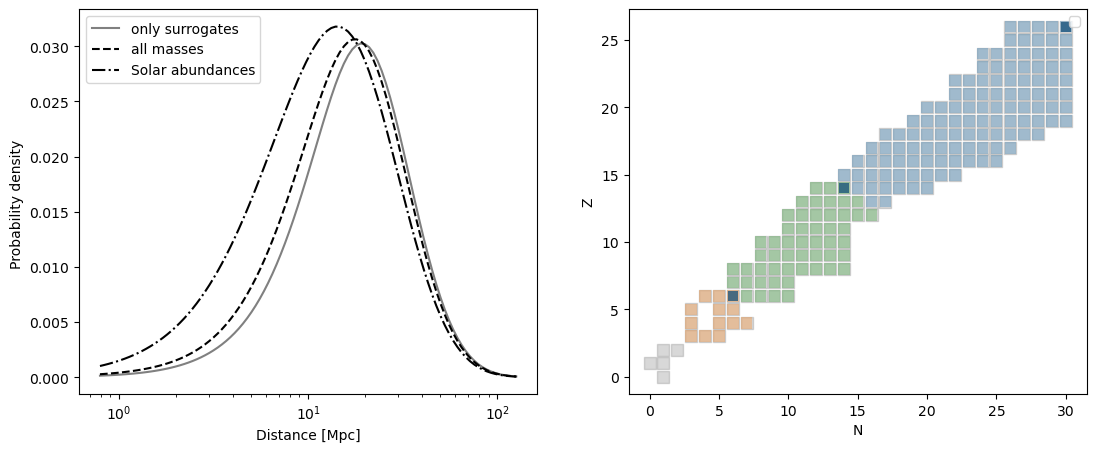

In [5]:
f, axes = plt.subplots(1, 2, figsize=(13, 5))

plt.sca(axes[0])
plt.semilogx(distances, total1[boostidx, :], label='only surrogates', c='grey')
plt.semilogx(distances, total2[boostidx, :], label='all masses', ls='--', c='k')
plt.semilogx(distances, total3[boostidx, :], label='Solar abundances', ls='-.', c='k')

plt.legend()

# plt.suptitle(f'Lorentz boost {br[boostidx]:2.1e}', fontsize=20)

plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability density ')
plt.sca(axes[1])

for z, a in ic1.species:
    plt.scatter(a-z, z, s=70, marker='s', c='grey', alpha=.3)

    if 28 < a <= 56:
        plt.scatter(a-z, z, s=70, marker='s', fc='C0', alpha=.3, ec='none')
    if 12 < a <= 28:
        plt.scatter(a-z, z, s=70, marker='s', fc='C2', alpha=.3, ec='none')
    if 4 < a <= 12:
        plt.scatter(a-z, z, s=70, marker='s', fc='C1', alpha=.3, ec='none')

for z, a in [(6, 12), (14, 28), (26, 56)]:
    plt.scatter(a-z, z, s=50, marker='s', fc='k', alpha=.5, ec='none')

for z, a in [(6, 12), (14, 28), (26, 56)]:
    plt.scatter(a-z, z, s=50, marker='s', fc='C0', alpha=.5, ec='none')

# plt.scatter([], [], marker='s', c='C0', alpha=.3, label=f'in crpropa ({len(ic1.nuclei)} species)')

plt.legend()
plt.xlabel('N')
plt.ylabel('Z')

Adding all possibilities of injection as a band

Text(0, 0.5, 'Probability Distribution')

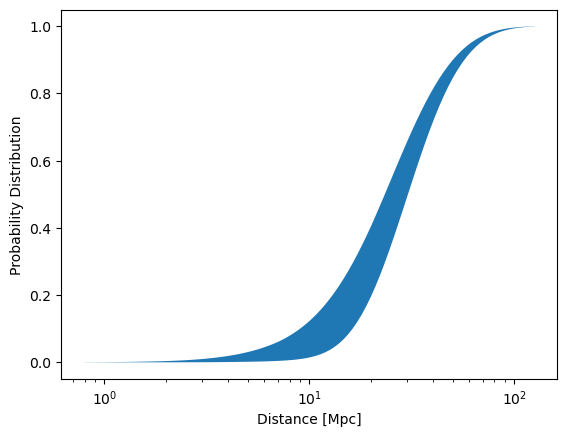

In [6]:
# Computing base distributions
alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(56, 2-1), injection_type=('only species', (26, 56)), absorption_type=('only mass', [2]))
_, total_56 = ic1.cdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(28, 2-1), injection_type=('only species', (14, 28)), absorption_type=('only mass', [2]))
_, total_28 = ic1.cdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(12, 2-1), injection_type=('only species', (6, 12)), absorption_type=('only mass', [2]))
_, total_12 = ic1.cdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

alpha, mr, tr = ic1.get_distribution_parameters(mass_lims=(4, 2-1), injection_type=('only species', (2, 4)), absorption_type=('only mass', [2]))
_, total_4 = ic1.cdf_boost_range(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

# finding all sort of combinations
np.random.seed(0)
n = np.random.rand(100, 3)
n /= np.repeat(np.sum(n, axis=1), 3).reshape(-1, 3)

all_combos = np.vstack([row[0]*total_12[boostidx, :] + row[1]*total_28[boostidx, :] + row[2]*total_56[boostidx, :] for row in n])
all_combos_min = np.min(all_combos, axis=0)
all_combos_max = np.max(all_combos, axis=0)

plt.fill_between(distances, all_combos_min, all_combos_max)
plt.semilogx()
plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability Distribution')

Text(0, 0.5, 'Probability Distribution')

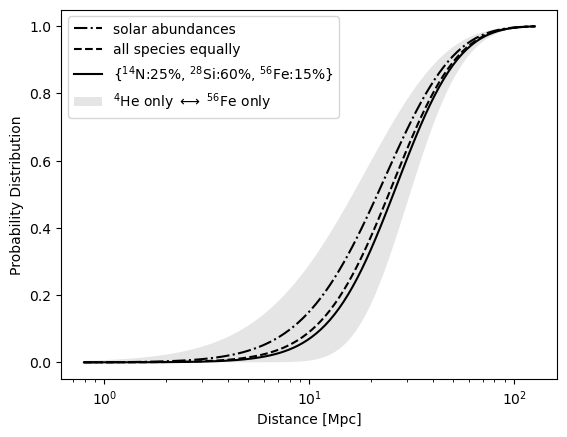

In [7]:
from scipy.integrate import cumtrapz
# f, axes = plt.subplots(1, 2, figsize=(13, 5))

# plt.sca(axes[0])
plt.semilogx(distances, cumtrapz(total3[boostidx, :], distances, initial=0), label='solar abundances', ls='-.', c='k')
plt.semilogx(distances, cumtrapz(total2[boostidx, :], distances, initial=0), label='all species equally', ls='--', c='k')
plt.semilogx(distances, cumtrapz(total1[boostidx, :], distances, initial=0), label='{$^{14} \mathrm{N}$:25%, $^{28}\mathrm{Si}$:60%, $^{56}\mathrm{Fe}$:15%}', c='k')
plt.fill_between(distances, total_4[boostidx, :], total_56[boostidx, :], alpha=.2, fc='grey', label='$^4\mathrm{He}$ only $\longleftrightarrow$ $^{56}\mathrm{Fe}$ only')
# plt.fill_between(distances, all_combos_min, all_combos_max, alpha=.2)

plt.legend()

plt.xlabel('Distance [Mpc]')
plt.ylabel('Probability Distribution')

## Computing production of light secondaries

In [8]:
light_prods = ic1.light_secondaries_production(distances, alpha, mass_range=mr, boost_range=br, true_range=tr)

Text(0.5, 1.0, 'Yields of light secondaries vs distance')

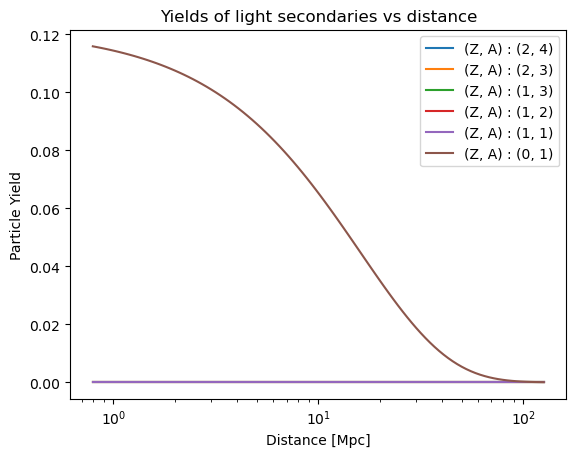

In [9]:
daughters = [(2, 4), (2, 3), (1, 3), (1, 2), (1, 1), (0, 1)]

for nuc, particle_yield in zip(daughters, light_prods[:, boostidx]):
    plt.semilogx(distances, particle_yield, label=f'(Z, A) : {nuc}')

plt.legend()

plt.xlabel('Distance [Mpc]')
plt.ylabel('Particle Yield')
plt.title('Yields of light secondaries vs distance')